# 07 - Model Comparison

Day 2, step 7. The same split, the same preprocessor, three algorithms:

* **Logistic Regression** - the explainable baseline from notebook 06
* **Random Forest** - picks up non-linear structure the linear model cannot
* **XGBoost** - usually the strongest on tabular data

Holding preprocessing constant matters. If each model got its own preparation, the
comparison would measure the preparation rather than the algorithm.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.model_selection import train_test_split

from app.utils.config import PROCESSED_FILES, RANDOM_STATE, TEST_SIZE
from pipelines.train_model import compare_models, select_winner

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

df = pd.read_csv(PROCESSED_FILES["attrition"])
y = df["AttritionFlag"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

## How each model is told about the imbalance

| Model | Mechanism |
|---|---|
| Logistic Regression | `class_weight="balanced"` |
| Random Forest | `class_weight="balanced_subsample"` |
| XGBoost | `scale_pos_weight = n_negative / n_positive` |

Each threshold is tuned on out-of-fold predictions from the training set only, so
the test metrics below are not contaminated by the tuning.

In [2]:
comparison, fitted, thresholds = compare_models(X_train, y_train, X_test, y_test)
comparison

2026-09-02 14:05:55 | INFO    | hr_ai.train | LogisticRegression: cv_auc=0.8354 test_auc=0.8006 test_recall=0.5532


2026-09-02 14:06:11 | INFO    | hr_ai.train | RandomForest: cv_auc=0.8122 test_auc=0.7672 test_recall=0.8085


2026-09-02 14:06:19 | INFO    | hr_ai.train | XGBoost: cv_auc=0.8076 test_auc=0.7754 test_recall=0.7660


,model,cv_roc_auc,cv_f2,threshold,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_f2
0,LogisticRegression,0.8354,0.6297,0.58,0.8006,0.5429,0.4262,0.5532,0.4815,0.5221
2,XGBoost,0.8076,0.6066,0.08,0.7754,0.4982,0.2835,0.7660,0.4138,0.5714
1,RandomForest,0.8122,0.6065,0.17,0.7672,0.4246,0.3089,0.8085,0.4471,0.6109


## Selecting a winner

**Selection uses ROC-AUC and PR-AUC only** - both threshold-independent.

This is a deliberate correction to the obvious approach. Ranking models by F1 or F2
would conflate two separate decisions, because each model carries its own tuned
threshold: a model can post an excellent F2 purely by cutting low enough to flag most
of the workforce. Random Forest below is exactly that case - the best F2 of the three,
achieved with 81% recall at 31% precision.

The first question is which model *orders* employees by risk best, since the risk
bands depend on that ordering. Where to cut is a second, separate decision.

In [3]:
scored = comparison.assign(combined=lambda d: 0.5 * d["test_roc_auc"] + 0.5 * d["test_pr_auc"])
print(scored[["model", "test_roc_auc", "test_pr_auc", "test_f2", "combined"]]
      .sort_values("combined", ascending=False).to_string(index=False))

winner = select_winner(comparison)
print(f"\nSelected: {winner}")

             model  test_roc_auc  test_pr_auc  test_f2  combined
LogisticRegression        0.8006       0.5429   0.5221   0.67175
           XGBoost        0.7754       0.4982   0.5714   0.63680
      RandomForest        0.7672       0.4246   0.6109   0.59590

Selected: LogisticRegression


## The result contradicts the plan, and that is the useful part

The build notes expected XGBoost to win, on the reasonable general principle that
gradient boosting usually dominates tabular problems. It did not.

**Logistic Regression wins on both threshold-independent metrics.** The reason is
sample size: 1,470 rows with 237 positives is a small dataset, and the signal in it -
overtime, job role, tenure, pay relative to tenure - is close to linear. Random Forest
and XGBoost have enough capacity to fit noise, and the cross-validation gap shows it:
both score meaningfully worse out-of-fold than the linear model.

This is why the notes insist on building a boring baseline first. Without it, XGBoost
would have been adopted on reputation and would have been the worse ranker.

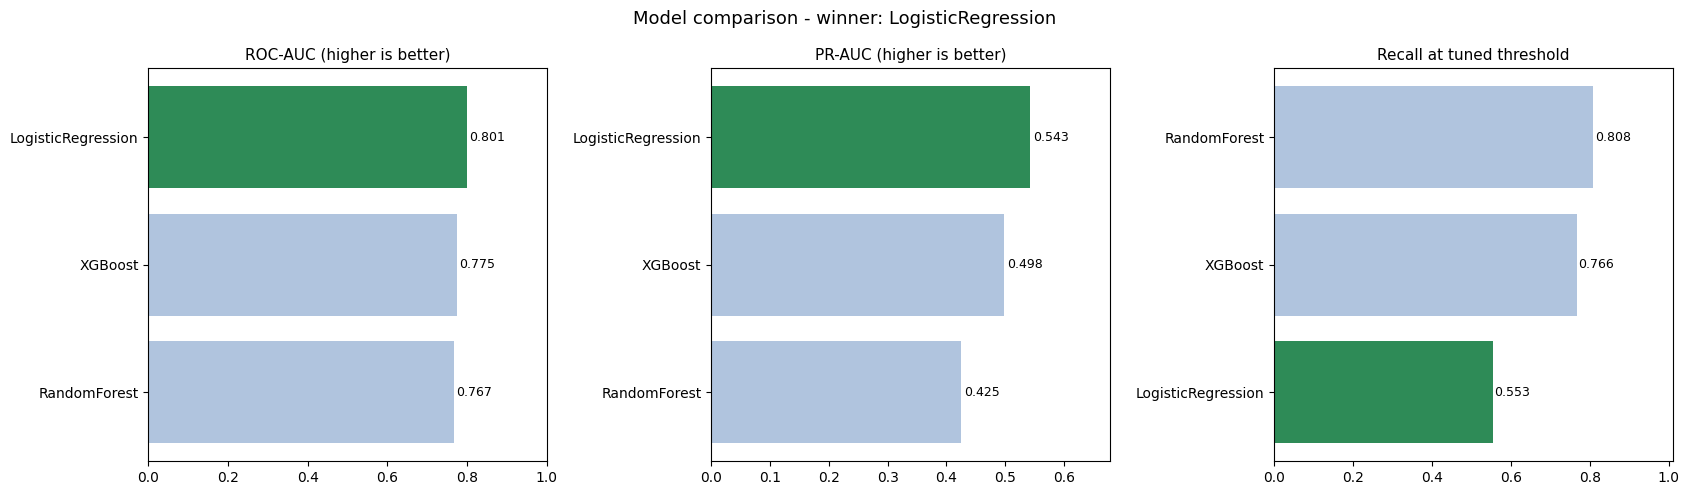

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metrics_to_plot = ["test_roc_auc", "test_pr_auc", "test_recall"]
titles = ["ROC-AUC (higher is better)", "PR-AUC (higher is better)", "Recall at tuned threshold"]
for ax, metric, title in zip(axes, metrics_to_plot, titles):
    ordered = comparison.sort_values(metric)
    colors = ["seagreen" if m == winner else "lightsteelblue" for m in ordered["model"]]
    ax.barh(ordered["model"], ordered[metric], color=colors)
    for i, v in enumerate(ordered[metric]):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, max(ordered[metric]) * 1.25)
fig.suptitle(f"Model comparison - winner: {winner}", fontsize=13)
fig.tight_layout()
plt.show()

The third panel makes the trap visible: Random Forest has by far the best recall, and
is still the worst ranker of the three. Recall alone, at a threshold the model chose
for itself, is not evidence of a better model.

## Curves for all three

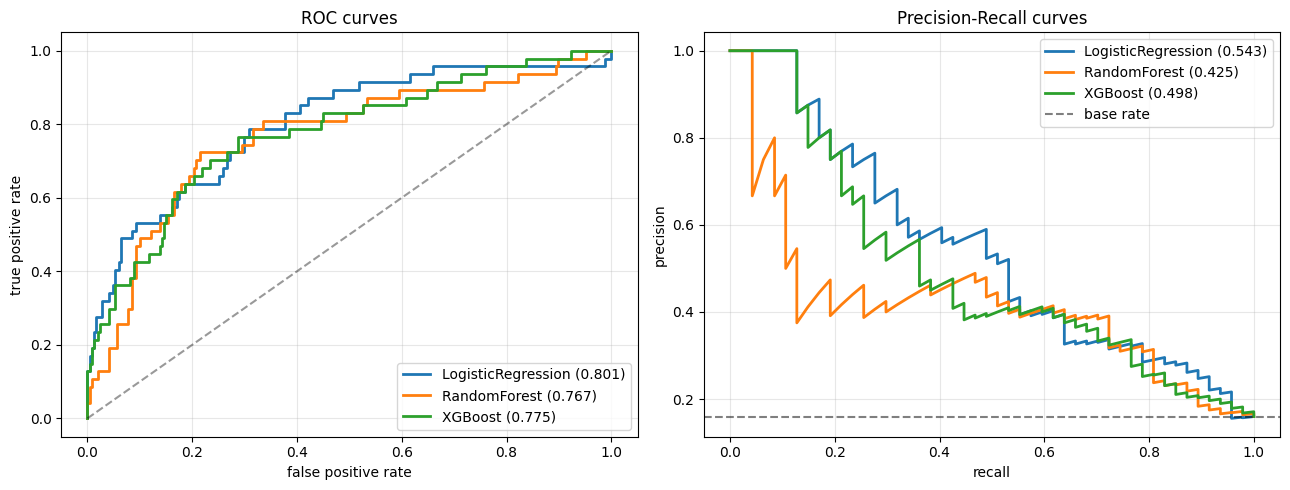

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for name, pipeline in fitted.items():
    p = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    precision, recall, _ = precision_recall_curve(y_test, p)
    auc = comparison.loc[comparison["model"] == name, "test_roc_auc"].iloc[0]
    ap = comparison.loc[comparison["model"] == name, "test_pr_auc"].iloc[0]
    ax1.plot(fpr, tpr, linewidth=2, label=f"{name} ({auc:.3f})")
    ax2.plot(recall, precision, linewidth=2, label=f"{name} ({ap:.3f})")

ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set(xlabel="false positive rate", ylabel="true positive rate", title="ROC curves")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.axhline(y_test.mean(), color="k", linestyle="--", alpha=0.5, label="base rate")
ax2.set(xlabel="recall", ylabel="precision", title="Precision-Recall curves")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Overfitting check

The gap between cross-validated and test ROC-AUC shows how much each model was
fitting noise.

In [6]:
gap = comparison[["model", "cv_roc_auc", "test_roc_auc"]].copy()
gap["gap"] = (gap["cv_roc_auc"] - gap["test_roc_auc"]).round(4)
gap.sort_values("gap")

,model,cv_roc_auc,test_roc_auc,gap
2,XGBoost,0.8076,0.7754,0.0322
0,LogisticRegression,0.8354,0.8006,0.0348
1,RandomForest,0.8122,0.7672,0.0450


## The cost of each model's mistakes

The build notes ask for selection based on the actual cost of errors, so it is worth
stating what each model's operating point would mean in practice.

In [7]:
rows = []
for name, pipeline in fitted.items():
    p = pipeline.predict_proba(X_test)[:, 1]
    predictions = (p >= thresholds[name]).astype(int)
    tp = int(((predictions == 1) & (y_test == 1)).sum())
    fp = int(((predictions == 1) & (y_test == 0)).sum())
    fn = int(((predictions == 0) & (y_test == 1)).sum())
    rows.append({
        "model": name,
        "threshold": thresholds[name],
        "leavers_caught": tp,
        "leavers_missed": fn,
        "stayers_flagged": fp,
        "total_flagged": tp + fp,
        "% of workforce flagged": round(100 * (tp + fp) / len(y_test), 1),
    })
pd.DataFrame(rows).sort_values("leavers_missed")

,model,threshold,leavers_caught,leavers_missed,stayers_flagged,total_flagged,% of workforce flagged
1,RandomForest,0.17,38,9,85,123,41.8
2,XGBoost,0.08,36,11,91,127,43.2
0,LogisticRegression,0.58,26,21,35,61,20.7


Random Forest catches the most leavers but asks HR to have a retention conversation
with roughly two in five of the entire test population - most of whom were never
going to leave. Logistic Regression flags a far smaller group with better precision,
while ranking risk more accurately overall.

Since the platform surfaces *ranked risk bands* rather than a raw yes/no, ordering
quality is what actually drives the product, and the linear model wins on it.

## Conclusion

`LogisticRegression` is promoted to `models/v1/`. Notebook 08 explains what it
learned; notebook 09 covers the versioning that makes any prediction traceable back
to the model that produced it.